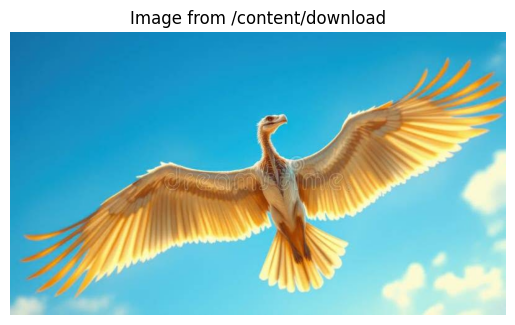

In [ ]:
import cv2
import matplotlib.pyplot as plt

image_path = '/content/download'

# Read the image using OpenCV
image = cv2.imread(image_path)

# Check if the image was loaded successfully
if image is not None:
    # OpenCV reads images in BGR format, so convert to RGB for displaying with Matplotlib
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Display the image
    plt.imshow(image_rgb)
    plt.axis('off') # Turn off axis numbers and ticks
    plt.title('Image from /content/download')
    plt.show()
else:
    print(f"Error: Could not load image from {image_path}. Please check the path and file integrity.")

In [ ]:
if image is not None:
    print(f"Image dimensions (height, width, channels): {image.shape}")
else:
    print("Image not loaded. Cannot display dimensions.")

Image dimensions (height, width, channels): (457, 800, 3)


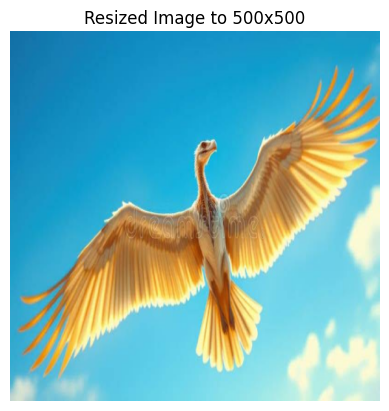

Resized image dimensions (height, width, channels): (500, 500, 3)


In [ ]:
if image is not None:
    # Define the new dimensions
    new_dim = (500, 500) # width, height

    # Resize the image
    resized_image = cv2.resize(image, new_dim, interpolation=cv2.INTER_AREA)

    # Convert the resized image to RGB for displaying with Matplotlib
    resized_image_rgb = cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB)

    # Display the resized image
    plt.imshow(resized_image_rgb)
    plt.axis('off')
    plt.title(f'Resized Image to {new_dim[0]}x{new_dim[1]}')
    plt.show()

    print(f"Resized image dimensions (height, width, channels): {resized_image.shape}")
else:
    print("Image not loaded. Cannot reshape or display.")

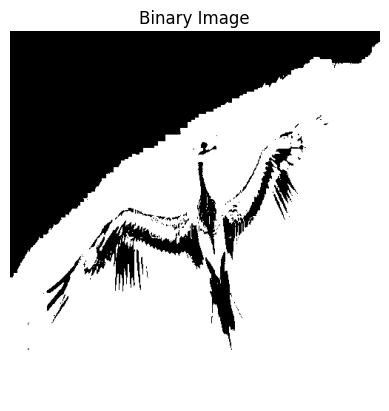

In [ ]:
if resized_image is not None:
    # Convert the resized image to grayscale
    gray_image = cv2.cvtColor(resized_image, cv2.COLOR_BGR2GRAY)

    # Apply binary thresholding
    # You might need to adjust the threshold value (e.g., 127) and max_value (e.g., 255) based on your image.
    # cv2.THRESH_BINARY creates a binary image where pixels above the threshold are set to max_value and below to 0.
    _, binary_image = cv2.threshold(gray_image, 127, 255, cv2.THRESH_BINARY)

    # Display the binary image
    plt.imshow(binary_image, cmap='gray') # Use 'gray' colormap for binary images
    plt.axis('off')
    plt.title('Binary Image')
    plt.show()
else:
    print("Resized image not available. Cannot convert to binary.")

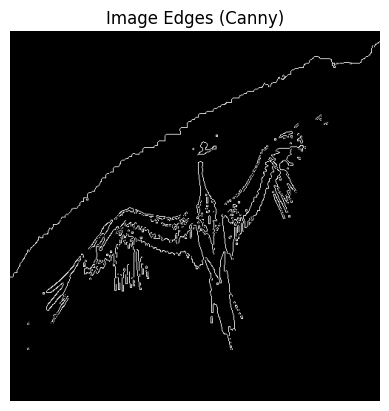

In [ ]:
if binary_image is not None:
    # Apply Canny edge detection
    # The Canny algorithm uses two thresholds (low and high) to detect strong and weak edges.
    # Edges with intensities greater than max_threshold are sure edges.
    # Edges with intensities between min_threshold and max_threshold are classified as edges
    # if they are connected to sure edges.
    # You might need to adjust these threshold values based on your image.
    edges = cv2.Canny(binary_image, 100, 200)

    # Display the edges
    plt.imshow(edges, cmap='gray')
    plt.axis('off')
    plt.title('Image Edges (Canny)')
    plt.show()
else:
    print("Binary image not available. Cannot detect edges.")

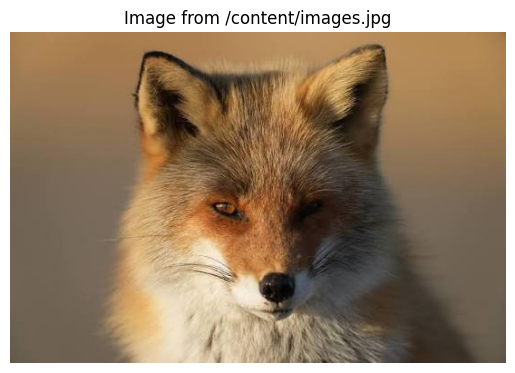

In [ ]:
import cv2
import matplotlib.pyplot as plt

new_image_path = '/content/images.jpg'

# Read the image using OpenCV
new_image = cv2.imread(new_image_path)

# Check if the image was loaded successfully
if new_image is not None:
    # OpenCV reads images in BGR format, so convert to RGB for displaying with Matplotlib
    new_image_rgb = cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB)

    # Display the image
    plt.imshow(new_image_rgb)
    plt.axis('off') # Turn off axis numbers and ticks
    plt.title(f'Image from {new_image_path}')
    plt.show()
else:
    print(f"Error: Could not load image from {new_image_path}. Please check the path and file integrity.")

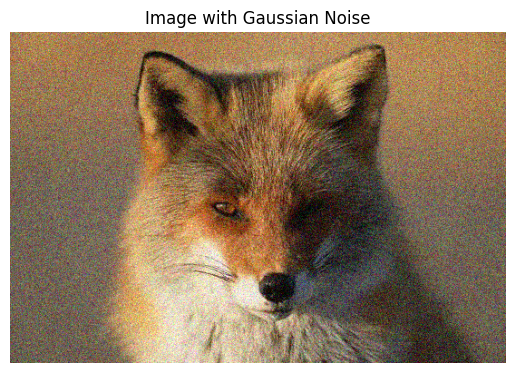

In [ ]:
import numpy as np

if new_image is not None:
    # Convert image to float32 for noise addition
    image_float = new_image.astype(np.float32) / 255.0 # Normalize to [0, 1]

    # Define parameters for Gaussian noise
    mean = 0
    std_dev = 0.1 # Standard deviation of the noise (adjust as needed)

    # Generate Gaussian noise
    noise = np.random.normal(mean, std_dev, image_float.shape).astype(np.float32)

    # Add noise to the image
    noisy_image_float = image_float + noise

    # Clip values to stay within [0, 1] and convert back to uint8
    noisy_image = np.clip(noisy_image_float, 0, 1) * 255
    noisy_image = noisy_image.astype(np.uint8)

    # Convert to RGB for display (if original was BGR)
    noisy_image_rgb = cv2.cvtColor(noisy_image, cv2.COLOR_BGR2RGB)

    # Display the noisy image
    plt.imshow(noisy_image_rgb)
    plt.axis('off')
    plt.title('Image with Gaussian Noise')
    plt.show()
else:
    print("Image not loaded. Cannot add Gaussian noise.")

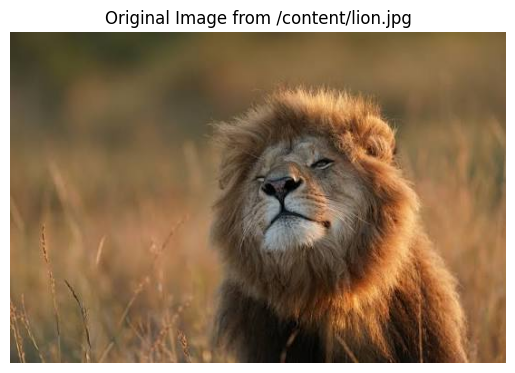

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

lion_image_path = '/content/lion.jpg'

# Read the image using OpenCV
lion_image = cv2.imread(lion_image_path)

# Check if the image was loaded successfully
if lion_image is not None:
    # Convert to RGB for displaying with Matplotlib
    lion_image_rgb = cv2.cvtColor(lion_image, cv2.COLOR_BGR2RGB)

    # Display the original image
    plt.imshow(lion_image_rgb)
    plt.axis('off')
    plt.title(f'Original Image from {lion_image_path}')
    plt.show()
else:
    print(f"Error: Could not load image from {lion_image_path}. Please check the path and file integrity.")

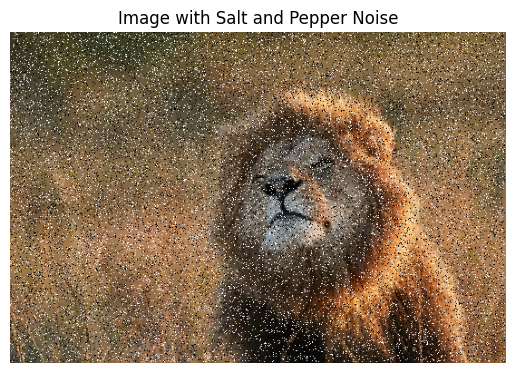

In [ ]:
def add_salt_and_pepper_noise(image, salt_vs_pepper, amount):
    '''Adds salt and pepper noise to an image.

    Args:
        image (numpy.ndarray): The input image.
        salt_vs_pepper (float): Ratio of salt to pepper noise (0 to 1). Higher means more salt.
        amount (float): The proportion of the image pixels to be corrupted (0 to 1).

    Returns:
        numpy.ndarray: The image with salt and pepper noise.
    '''
    noisy_image = np.copy(image)
    # Get number of pixels
    num_salt = np.ceil(amount * image.size * salt_vs_pepper)
    num_pepper = np.ceil(amount * image.size * (1 - salt_vs_pepper))

    # Add Salt noise
    coords = [np.random.randint(0, i - 1, int(num_salt))
              for i in image.shape]
    noisy_image[coords[0], coords[1], :] = 255

    # Add Pepper noise
    coords = [np.random.randint(0, i - 1, int(num_pepper))
              for i in image.shape]
    noisy_image[coords[0], coords[1], :] = 0
    return noisy_image


if lion_image is not None:
    # Add salt and pepper noise (e.g., 50% salt, 50% pepper, 5% of pixels corrupted)
    salt_pepper_noisy_image = add_salt_and_pepper_noise(lion_image, 0.5, 0.05)

    # Convert to RGB for displaying with Matplotlib
    salt_pepper_noisy_image_rgb = cv2.cvtColor(salt_pepper_noisy_image, cv2.COLOR_BGR2RGB)

    # Display the noisy image
    plt.imshow(salt_pepper_noisy_image_rgb)
    plt.axis('off')
    plt.title('Image with Salt and Pepper Noise')
    plt.show()
else:
    print("Image not loaded. Cannot add salt and pepper noise.")

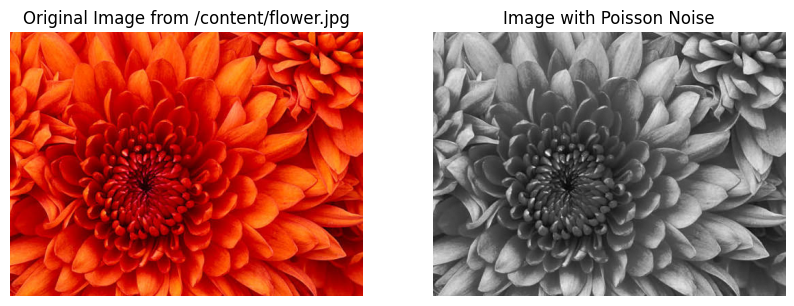

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

flower_image_path = '/content/flower.jpg'

# Read the image using OpenCV
flower_image = cv2.imread(flower_image_path)

# Check if the image was loaded successfully
if flower_image is not None:
    # Convert to RGB for displaying with Matplotlib
    flower_image_rgb = cv2.cvtColor(flower_image, cv2.COLOR_BGR2RGB)

    # Display the original image
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(flower_image_rgb)
    plt.axis('off')
    plt.title(f'Original Image from {flower_image_path}')

    # Convert the image to grayscale for Poisson noise (often applied to photon counts)
    gray_flower_image = cv2.cvtColor(flower_image, cv2.COLOR_BGR2GRAY)

    # Apply Poisson noise
    # Scale image to appropriate range for Poisson distribution (e.g., 0-255)
    # The lambda parameter in Poisson distribution is the mean/variance of the counts.
    # A higher lambda makes the noise less noticeable.
    # We'll normalize to [0,1], multiply by a factor (e.g., 50 for photon count), add noise, then scale back.
    # Cast to float to avoid overflow issues during noise addition
    vals = len(np.unique(gray_flower_image)) # Number of unique intensity values
    vals = 2 ** np.ceil(np.log2(vals)) # Scale to the nearest power of 2
    noisy_poisson_image = np.random.poisson(gray_flower_image * vals) / float(vals)

    # Clip values to stay within [0, 255] and convert back to uint8
    noisy_poisson_image = np.clip(noisy_poisson_image, 0, 255).astype(np.uint8)

    # Display the noisy image
    plt.subplot(1, 2, 2)
    plt.imshow(noisy_poisson_image, cmap='gray') # Poisson noise on grayscale
    plt.axis('off')
    plt.title('Image with Poisson Noise')
    plt.show()
else:
    print(f"Error: Could not load image from {flower_image_path}. Please check the path and file integrity.")